Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE" and remove every line containing the expression: "raise ..." (if you leave such a line your code will not run).

Do not remove any cell from the notebook you downloaded. You can add any number of cells (and remove them if not more necessary).

Do not leave any variable initialized to None.

## IMPORTANT: make sure to rerun all the code from the beginning to obtain the results for the final version of your notebook, since this is the way we will do it before evaluating your notebook!!!

## Make sure to name your notebook file (.ipynb) correctly:
### - UL_NAMESURNAME_ID (E.g. : UL_MARIOROSSI_2204567)

## Fill in your name, surname and id number (numero matricola) below:

In [1]:
# Reproducible project seed, not a university registration number.
NAME = "Stelina Mukaj"
ID_number = 42  # Replace with your matricola only if submitting to the course.
import numpy as np
np.random.seed(ID_number)


---

# HOMEWORK #4

## Unsupervised learning

In this notebook we are going to explore the use of unsupervised clustering methods.

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from scipy.stats import multivariate_normal
from sklearn.datasets import make_blobs


In [3]:
def gv_normalizing_const(sigma):
    sigma = np.atleast_2d(sigma)
    sign,logdet = np.linalg.slogdet(sigma)
    if sign <= 0:
        raise ValueError("Covariance must be positive definite")
    return np.float64(np.exp(-0.5*(len(sigma)*np.log(2*np.pi)+logdet)))

def gaussian_pdf(x,mu,sigma):
    diff = np.asarray(x).reshape(-1,1)-np.asarray(mu).reshape(-1,1)
    return gv_normalizing_const(sigma)*np.exp(-0.5*(diff.T @ np.linalg.solve(sigma,diff)))


In [4]:
assert type(gv_normalizing_const(np.array([[2.]]))) == np.float64
# Test on scalar case
x = np.array([[1.]])
mean, cov = np.array([[2.5]]), np.array([[0.5]])
assert np.isclose(multivariate_normal.pdf(1, mean=mean.ravel(), cov=cov), gaussian_pdf(x, mean, cov), atol=1e-3)

# Test on vector valued case
mean, temp = np.random.normal(2, 3, 2).reshape(-1,1), np.random.normal(2, 3, 4).reshape(2,2)
x = np.random.normal(2, 3, 2).reshape(-1,1)
cov = temp @ temp.T
hand_pdf = gaussian_pdf(x, mean, cov)
scipy_pdf = multivariate_normal.pdf(x.reshape(1,-1)[0], mean.reshape(1,-1)[0], cov)
assert np.isclose(hand_pdf, scipy_pdf, atol=1e-4)


Let's load a 1-D dataset which does not contain any label. It has been generated using K clusters.

Can you tell how many clusters have been used by looking at the scatter plot?

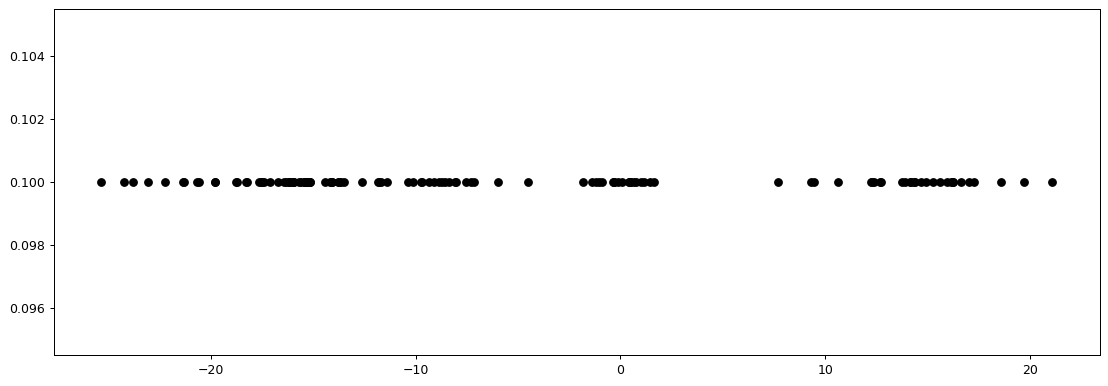

In [5]:
url = 'https://raw.githubusercontent.com/LucaZancato/ML2020-2021/main/HW_4/1_D_dataset.csv'
data = np.array(pd.read_csv(url, sep=';'))

plt.figure(figsize=(15,5))
for i, x in enumerate(data):
    plt.scatter(x, 0.1, color='k')


It's not trivial to understand how many clusters are present. Such an issue is present also in the case of Expectation-Maximization (EM) on Gaussian Mixture Models (GMM) (the one we are going to implement) and K-means: for both of these algorithms the number of clusters is fixed a priori, it is a parameter (hyper-parameter) we must decide before processing any data.

Usually, in order to achieve satisfactory clustering, one needs to try with different number of classes and validate which is the best number. 

For now let's make it simple and let's consider the dataset has 3 clusters.

In the following cell we shall parametrize 3 Gaussian random variables specifiying both means, covariances and mixing probabilities. Take a moment to understand the way these parameters are stored, since the EM implementation is built on this notation. For now, means, cov and mixing probabilities are chosen without any specific criteria: we will see how EM applied to GMM will provide us a suboptimal set of means, covariances and mixing probabilities.

### Implemented updates
For responsibilities $r_{ik}$, let $N_k=\sum_i r_{ik}$. Then
$$r_{ik}=\frac{\pi_k\mathcal N(x_i;\mu_k,\Sigma_k)}{\sum_j\pi_j\mathcal N(x_i;\mu_j,\Sigma_j)},\quad
\pi_k=\frac{N_k}{N},\quad \mu_k=\frac{\sum_i r_{ik}x_i}{N_k},$$
$$\Sigma_k=\frac{1}{N_k}\sum_i r_{ik}(x_i-\mu_k)(x_i-\mu_k)^T.$$
The implementation adds $10^{-6}I$ to each covariance for numerical stability and computes posterior normalization in log space.


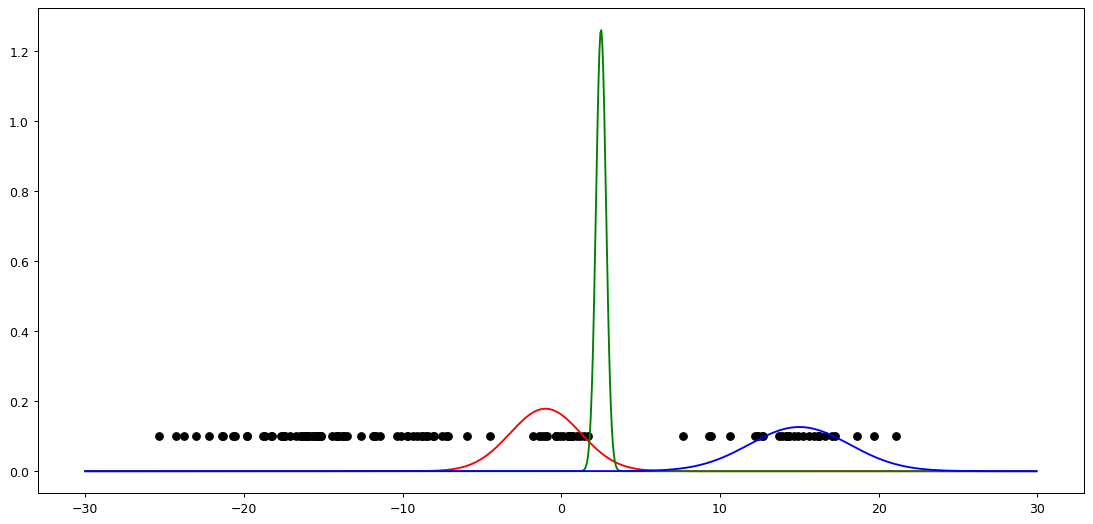

In [6]:
means = np.array([[-1],[2.5],[15]])      # shape (K,d)
covs  = np.array([[[5]],[[0.1]],[[10]]]) # shape (K,d,d) 
pi    = np.array([1/2, 1/4, 1/4])        # shape (K,)

X = np.linspace(-30, 30, 1000, endpoint=False).reshape(-1,1)

plt.figure(figsize=(15,7))
for i, x in enumerate(data):
    plt.scatter(x, 0.1, color='k')
plt.plot(X, [gaussian_pdf(x, means[0], covs[0]).item() for x in X], color='r')
plt.plot(X, [gaussian_pdf(x, means[1], covs[1]).item() for x in X], color='g')
plt.plot(X, [gaussian_pdf(x, means[2], covs[2]).item() for x in X], color='b')


In [7]:
def update_pi(W):
    return np.sum(W,axis=0)/len(W)

def update_means(data,W):
    counts = W.sum(axis=0)
    if np.any(np.abs(counts)<1e-15):
        raise ValueError("A component has zero effective observations")
    return (W.T @ data)/counts[:,None]

def update_covs(data,W,new_means):
    covs = []
    for k,mean in enumerate(new_means):
        centered = data-mean
        cov = (centered.T * W[:,k]) @ centered/W[:,k].sum()
        covs.append(cov)
    return np.asarray(covs)

def M_step(data,W):
    pi = update_pi(W)
    means = update_means(data,W)
    covs = update_covs(data,W,means)
    # A small ridge prevents degenerate components in actual EM runs.
    covs += 1e-6*np.eye(data.shape[1])[None,:,:]
    return pi,means,covs


In [8]:
W = np.array([[0.5, 0.5, 0],[0.5, 0, 0.5]])
assert np.isclose(update_pi(W), [0.5 , 0.25, 0.25], atol=1e-4).all()
W = np.random.normal(0,1, 1000).reshape(-1, 25) # Note this W is not normalized properly, we do not care not since we are testing only the output shape is correct
assert update_pi(W).shape == (25,)
# Test on the means update function
a = np.random.normal(0,1, 80).reshape(-1, 2)
b = update_means(a, W)
assert b.shape  == (25, 2)
# Test on the covs update function
assert update_covs(a, W, b).shape == (25, 2, 2)


In [9]:
from scipy.special import logsumexp

def component_log_probabilities(data,pi,means,covs):
    data = np.asarray(data,dtype=float)
    values = np.empty((len(data),len(pi)))
    for k in range(len(pi)):
        diff = data-means[k]
        sign,logdet = np.linalg.slogdet(covs[k])
        if sign <= 0:
            raise ValueError("Covariance is not positive definite")
        quadratic = np.sum(diff*np.linalg.solve(covs[k],diff.T).T,axis=1)
        values[:,k] = np.log(max(pi[k],np.finfo(float).tiny))-0.5*(data.shape[1]*np.log(2*np.pi)+logdet+quadratic)
    return values

def E_step(data,pi,means,covs):
    # Same Gaussian formula as gaussian_pdf, evaluated in log space to avoid underflow.
    joint = component_log_probabilities(data,pi,means,covs)
    return np.exp(joint-logsumexp(joint,axis=1,keepdims=True))


In [10]:
assert E_step(data, pi, means, covs).shape == (119, 3)
assert np.isclose(np.sum(E_step(data, pi, means, covs).sum(1) - 1), 0, atol=1e-4)


In [11]:
def randomly_initialize_W(data,num_classes):
    n = len(data)
    if not 1 <= num_classes <= n:
        raise ValueError("Need between 1 and N clusters")
    assignments = np.repeat(np.arange(num_classes),n//num_classes)
    assignments = np.r_[assignments,np.zeros(n % num_classes,dtype=int)]
    assignments = np.random.permutation(assignments)
    return np.eye(num_classes)[assignments]

def random_init(data,num_classes):
    W = randomly_initialize_W(data,num_classes)
    pi,means,covs = M_step(data,W)
    return W,pi,means,covs


In [12]:
assert (randomly_initialize_W(np.random.normal(0,1, 100).reshape(-1,10), 5).sum(0) == 2).all()
assert (randomly_initialize_W(np.random.normal(0,1, 100).reshape(-1,5), 2).sum(0) == 10).all()
assert (randomly_initialize_W(np.random.normal(0,1, 100).reshape(-1,5), 3).sum(0) -6 == 2).any()


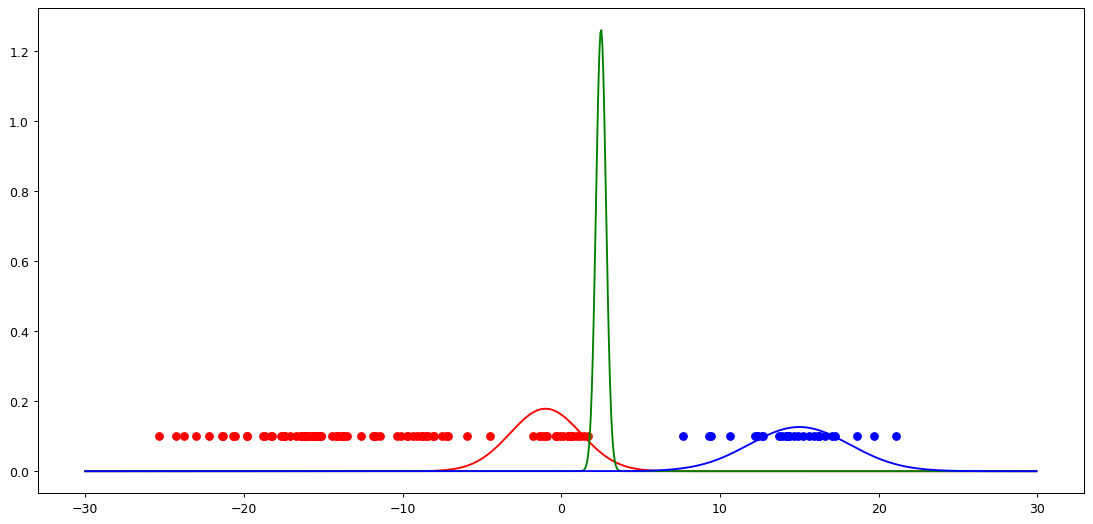

In [13]:
# Let's evaluate the class probability of each datum given current pi, means and covs. 
# Since we have 3 clusters we shall colour-code (rgb) each datum according to the class probabilities. Note that 
# it is not very likely to have a datum coming from the central (very peaked) distribution. 
W = E_step(data, pi, means, covs)

plt.figure(figsize=(15,7))
for i, x in enumerate(data):
    plt.scatter(x, 0.1, color=np.array([W[i][0], W[i][1], W[i][2]]))
plt.plot(X, [gaussian_pdf(x, means[0], covs[0]).item() for x in X], color='r')
plt.plot(X, [gaussian_pdf(x, means[1], covs[1]).item() for x in X], color='g')
plt.plot(X, [gaussian_pdf(x, means[2], covs[2]).item() for x in X], color='b')


In [14]:
def log_likelihood_GMM(data,pi,means,covs):
    # log(sum_k pi_k * Gaussian(x_i)) accumulated stably over observations.
    return np.float64(logsumexp(component_log_probabilities(data,pi,means,covs),axis=1).sum())


In [15]:
assert type(log_likelihood_GMM(data, pi, means, covs)) == np.float64


K=3, iterations=58, stop=likelihood tolerance, log likelihood=-420.3735, delta=0.000102


Text(0, 0.5, 'Log likelihood')

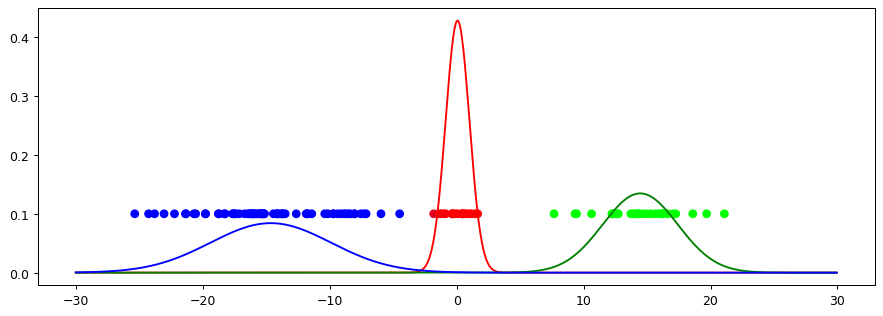

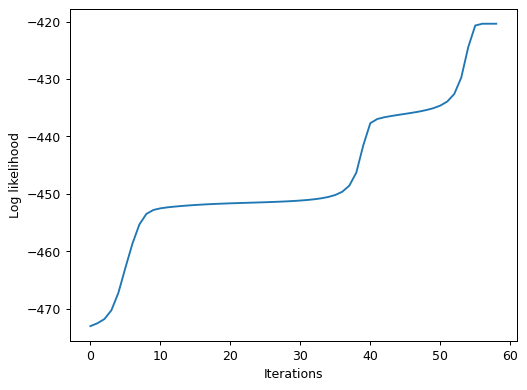

In [16]:
def run_EM_on_GMM(data,number_clusters,max_iter,epsilon=1e-3,plot_intermediate=False):
    data = np.asarray(data,dtype=float)
    if max_iter < 1 or epsilon < 0:
        raise ValueError("Require positive max_iter and nonnegative epsilon")
    W,pi,means,covs = random_init(data,number_clusters)
    history = [log_likelihood_GMM(data,pi,means,covs)]
    reason = 'maximum iterations'
    for iteration in range(1,max_iter+1):
        W = E_step(data,pi,means,covs)
        pi,means,covs = M_step(data,W)
        history.append(log_likelihood_GMM(data,pi,means,covs))
        delta = history[-1]-history[-2]
        if plot_intermediate and data.shape[1] == 2 and (iteration == 1 or iteration % 25 == 0 or abs(delta)<epsilon or iteration==max_iter):
            gx,gy = np.meshgrid(np.linspace(data[:,0].min()-1,data[:,0].max()+1,100),
                                np.linspace(data[:,1].min()-1,data[:,1].max()+1,100))
            pos = np.dstack((gx,gy))
            plt.figure(figsize=(9,4))
            for k in range(number_clusters):
                plt.contour(gx,gy,multivariate_normal(means[k],covs[k]).pdf(pos))
            plt.scatter(data[:,0],data[:,1],s=12)
            plt.title(f'EM iteration {iteration}'); plt.show()
        if abs(delta)<epsilon:
            reason = 'likelihood tolerance'
            break
    # Return responsibilities consistent with the final fitted parameters.
    W = E_step(data,pi,means,covs)
    print(f'K={number_clusters}, iterations={iteration}, stop={reason}, log likelihood={history[-1]:.4f}, delta={delta:.6f}')
    return W,pi,means,covs,history

max_iter = 150
W,pi,means,covs,log_likelihood_train = run_EM_on_GMM(data,3,max_iter)
ll_1d = list(log_likelihood_train)
plt.figure(figsize=(12,4))
plt.scatter(data[:,0],np.full(len(data),0.1),c=W)
for k,color in enumerate(['r','g','b']):
    plt.plot(X.ravel(),[gaussian_pdf(x,means[k],covs[k]).item() for x in X],color=color)
plt.figure();plt.plot(log_likelihood_train);plt.xlabel('Iterations');plt.ylabel('Log likelihood')


In [17]:
a, b, c, d, e = run_EM_on_GMM(data, 3, 10, plot_intermediate=False)
assert a.shape == (119, 3)
assert b.shape == (3,)
assert c.shape == (3, 1)
assert d.shape == (3, 1, 1)


K=3, iterations=10, stop=maximum iterations, log likelihood=-459.2927, delta=4.268328


We shall now try the same procedure with a 2-dimensional dataset.

Everything is the same as before but we can apprecaite a better visualization.

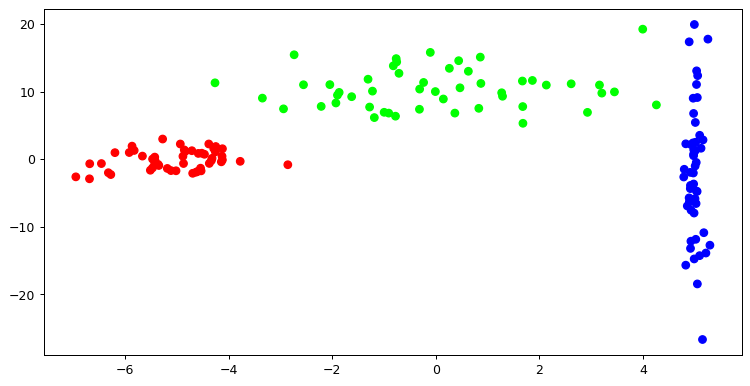

In [18]:
K = 3
clusters_cov = np.array([[1,2],[2,3],[0.1,10]])  # coordinate-wise standard deviations
centers = [[-5,0],[0,10.5],[5,-1]]
def anisotropic_blobs(centers,scales,seed,n_per_cluster=50):
    rng = np.random.default_rng(seed)
    points = np.vstack([rng.normal(loc=center,scale=scale,size=(n_per_cluster,2)) for center,scale in zip(centers,scales)])
    labels = np.repeat(np.arange(len(centers)),n_per_cluster)
    order = rng.permutation(len(points))
    return points[order],labels[order]
X,Y = anisotropic_blobs(centers,clusters_cov,ID_number)
colormap = np.array(['red','lime','blue'])
plt.figure(figsize=(10,5));plt.scatter(X[:,0],X[:,1],c=colormap[Y])


K=3, iterations=13, stop=likelihood tolerance, log likelihood=-684.8653, delta=0.000118


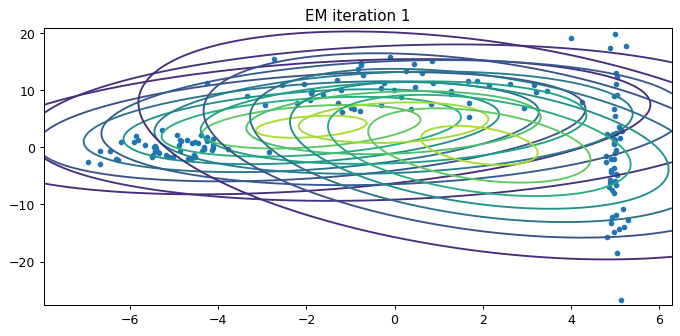

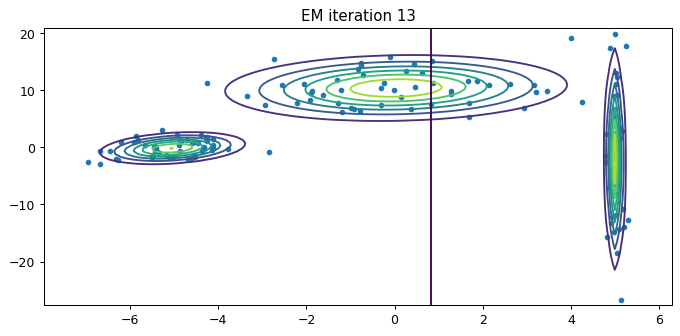

In [19]:
# Depending on your implementation this cell might take a while to run... (this is mainly due to the plots)
W, pi, means, covs, log_likelihood_train = run_EM_on_GMM(X, K, 150, plot_intermediate=True)


Text(0, 0.5, 'Log likelihood')

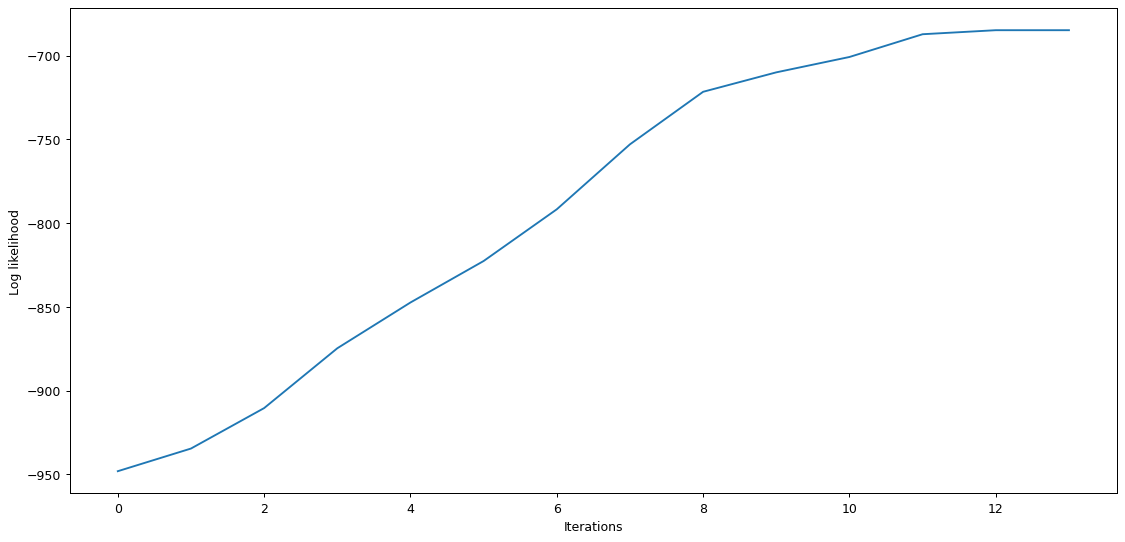

In [20]:
plt.figure(figsize=(15,7))
plt.plot(log_likelihood_train)
plt.xlabel('Iterations')
plt.ylabel('Log likelihood')


## TODO 7: explain the results you got (max 10 lines)

1-D dataset:
- Compare plots in to do 4 with the ones in to do 6, what has changed? Is EM providing us a meaningful clustering? 

2-D dataset:
- Why is the log likelihood monotonically increasing? Is this what you expect from the theory? Compare both log likelihood trajectory and 2-d plots.
- Is delta log likelihood monotonically going to zero?  
- Which termination criterion is met first?

(Answer in the next cell, no need to add code)

In 1-D, EM moves the arbitrary initial component parameters toward the observed density and changes the posterior color assignments. With seed 42 it stops after 58 updates by likelihood tolerance, at total log likelihood -420.3735; interpretable peaks support meaningful clustering without proving a unique latent partition.
In 2-D, elliptical contours adapt to location and covariance. Exact EM cannot decrease observed-data likelihood because each E/M step improves a tight lower bound; the tiny covariance ridge is a numerical safeguard and can cause small deviations from exact monotonicity.
The likelihood increments need not themselves decrease monotonically. In this run the 2-D algorithm reaches the likelihood tolerance after 13 updates, before the 150-update limit, with log likelihood -684.8653.

In [21]:
# What is the effect of choosing a different number of classes?
centers = [[-2, 0], [0, 3], [2, -1]]
X,Y = anisotropic_blobs(centers,clusters_cov,20)

Ks = [2, 3, 4, 5, 6]
results = []
for k in Ks:
    results.append(run_EM_on_GMM(X, k, 150, plot_intermediate=False))


K=2, iterations=13, stop=likelihood tolerance, log likelihood=-677.3170, delta=0.000097
K=3, iterations=33, stop=likelihood tolerance, log likelihood=-668.2372, delta=0.000774
K=4, iterations=150, stop=maximum iterations, log likelihood=-657.5427, delta=0.001460
K=5, iterations=130, stop=likelihood tolerance, log likelihood=-651.0336, delta=0.000878
K=6, iterations=150, stop=maximum iterations, log likelihood=-654.5436, delta=0.021267


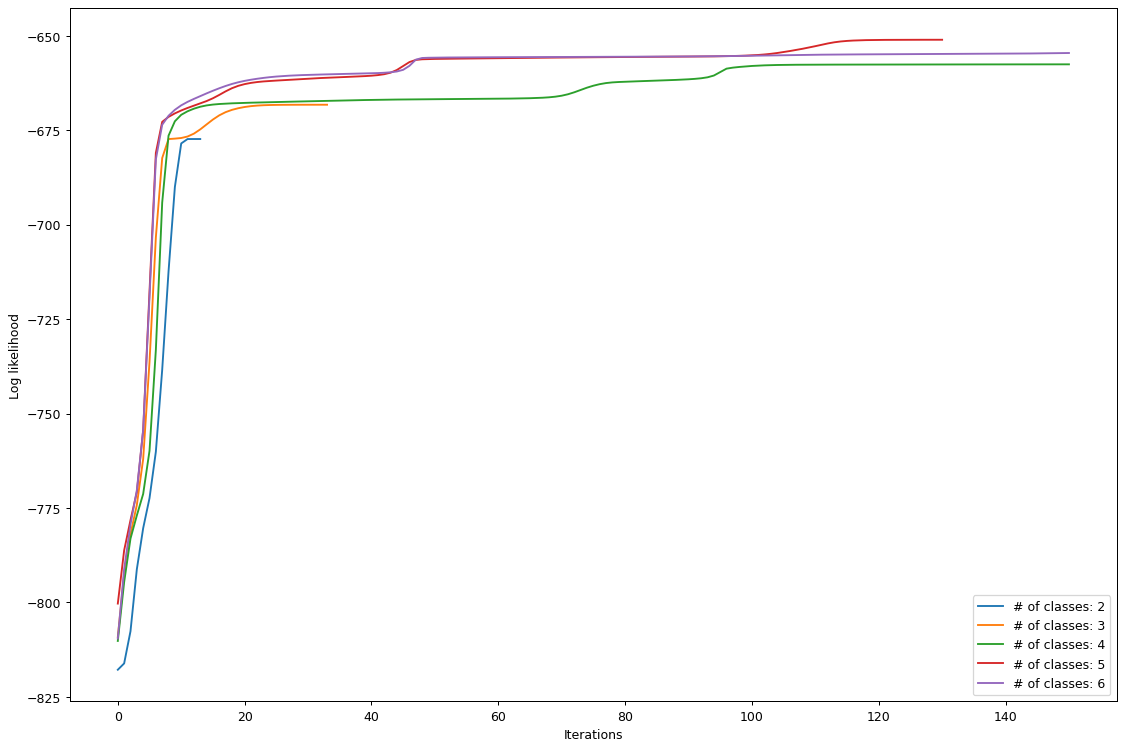

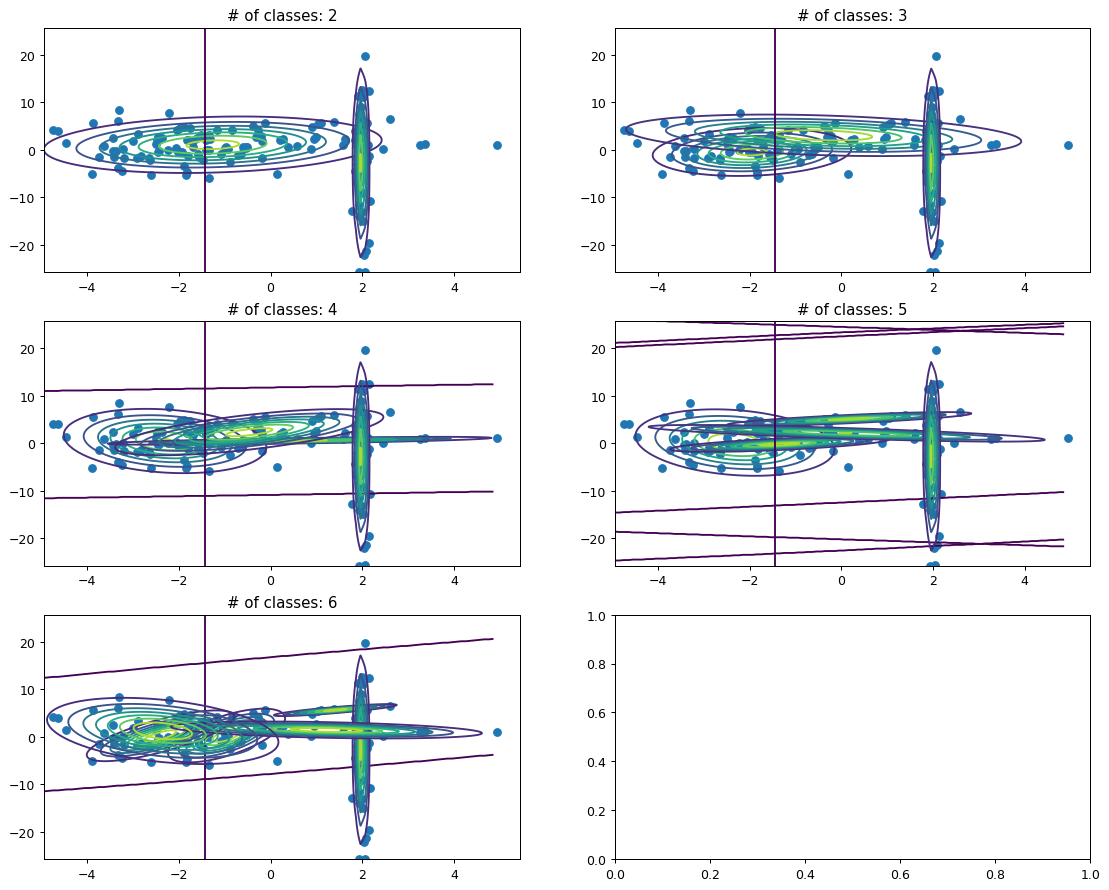

In [22]:
# Let's plot the log likelihood trajectories and the final 2-d Clustering
plt.figure(figsize=(15,10))
for res, k in zip(results, Ks): 
    plt.plot(np.array(res[-1]), label=f'# of classes: {k}')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Log likelihood')

x_max, y_max = np.max(np.abs(X[:,0])), np.max(np.abs(X[:,1]))
x, y = np.mgrid[-x_max:x_max:.10, -y_max:y_max:.10]
pos = np.dstack((x, y))

fig, axes = plt.subplots(3, 2, figsize=(15,12))
# Plot scatter plot of training data and corresponding clusters    
for (_, pi, means, covs, _), K, ax in zip(results, Ks, axes.reshape(-1,)): 
    for k in range(K):
        ax.contour(x, y, multivariate_normal(means[k], covs[k]).pdf(pos), )
    ax.scatter(X[0:,0], X[0:,1])
    ax.set_title(f'# of classes: {K}')


# MNIST clustering

Let's apply GMM to a slightly more complex dataset: MNIST (which we already encountered in the last homework).

In the following we shall use the sklearn implementation of the EM.

Once we fit the GMM we shall visualize the centers in order to evaluate whether the clustering algorithm came up with a meaningful solution (in an ideal scenario we would expect to have each center representing one single digit).

In [23]:
from sklearn.datasets import fetch_openml
from sklearn.mixture import GaussianMixture
import sklearn

X, Y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=True)
    
X = X / 255.

from sklearn.model_selection import train_test_split

m_t = 5000
x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=m_t, random_state=ID_number, 
                                                    stratify=Y)

# Function to plot a digit and print the corresponding label
def plot_digit(vect_img, ax, cluster_id=None):
    ax.set_title(f'Cluster ID: {cluster_id}')
    ax.imshow(
        vect_img.reshape(28,28),
        cmap          = 'gray',
        interpolation = "nearest"
    )


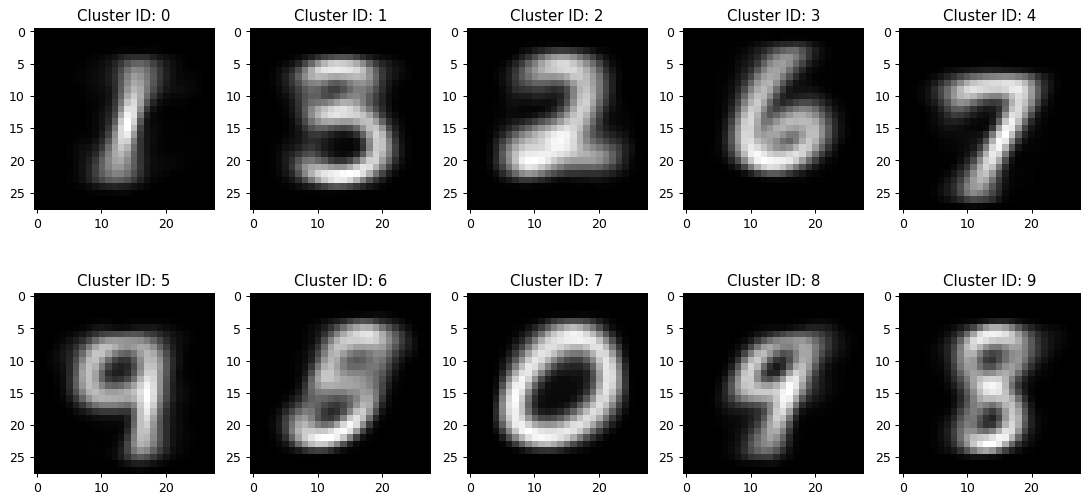

In [24]:
from sklearn.mixture import GaussianMixture
K = 10
# Full covariance preserves the assignment's model; regularize constant pixel directions.
gmm = GaussianMixture(n_components=K,covariance_type='full',reg_covar=1e-6,random_state=ID_number,max_iter=100)
gmm_pred = gmm.fit_predict(x_train)
plt1,axes = plt.subplots(2,K//2,figsize=(15,7))
for k,ax in zip(range(K),axes.ravel()):
    plot_digit(gmm.means_[k],ax,cluster_id=k)


In [25]:
assert gmm_pred.shape == (m_t,)


The weight used for initialization are [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


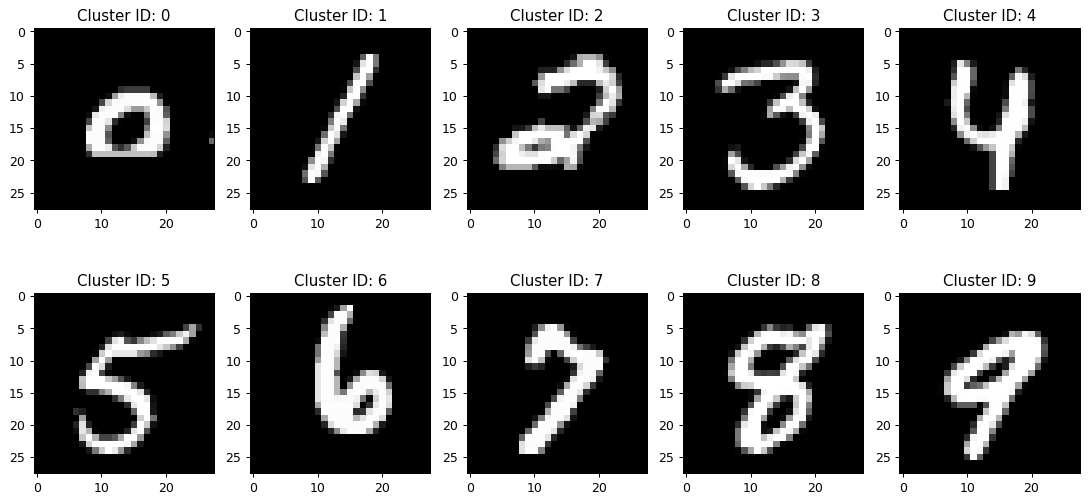

In [26]:
#let's try to initialize the means of the gmm using the first instance of each digit (0-9) present in the training set.

means = np.zeros((10,x_train.iloc[0].to_numpy().reshape(1,-1).shape[1]))
weights = np.ones((1,10))[0]*1/K

for k in range(10):
    first_numb = 0
    while not (int(y_train.iloc[first_numb]) == k):
        first_numb = first_numb+1
    means[k,:] = x_train.iloc[first_numb].to_numpy().reshape(1,-1)

#print the digits used for initialization
plt2, axes = plt.subplots(2, K // 2,figsize=(15,7))
for k, ax in zip(range(K), axes.reshape(-1,)):
    plot_digit(means[k], ax, cluster_id=k)

#print the wheighs used for initialization    
print(f'The weight used for initialization are {weights}')


In [27]:
# Label-informed initialization is a supervised aid, not a purely unsupervised experiment.
gmm = GaussianMixture(n_components=K,weights_init=weights,means_init=means,
                      random_state=ID_number,reg_covar=1e-6,max_iter=100)
gmm_pred = gmm.fit_predict(x_train)


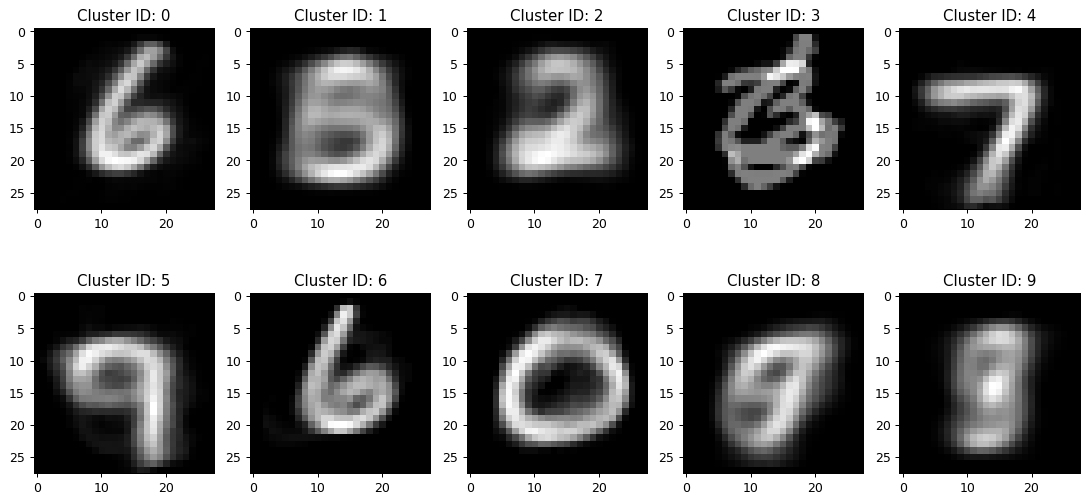

In [28]:
#ploting the means
plt3, axes = plt.subplots(2, K // 2,figsize=(15,7))
for k, ax in zip(range(K), axes.reshape(-1,)):
    plot_digit(gmm.means_[k], ax, cluster_id=k)


# Comparison with supervised models: 
In the next cell we shall compare Unsupervised methods (Kmeans and GMM) with a
Supervised method (NNs) on MNIST. 
Note that supervised methods cannot be applied in the unsupervised setting (i.e. we do not have any label). 
Nonetheless we can apply an unsupervised method to a supervised problem (we just need to neglect the extra piece 
of information we have: the labels). 
In the following we shall train both Kmeans and GMM as if we do not have labels and then we shall compare their
predictions to the ground truth labels. 

NOTE: in an unsupervised scenario we are not able to compare model predictions with ground truth labels since 
labels are not part of the problem statement.

In [29]:
def cluster_label_mapping(targets,predictions,num_clusters):
    targets,predictions = np.asarray(targets),np.asarray(predictions)
    labels,counts = np.unique(targets,return_counts=True)
    fallback = labels[np.argmax(counts)]
    mapping = []
    for k in range(num_clusters):
        members = targets[predictions==k]
        if len(members):
            values,counts = np.unique(members,return_counts=True)
            mapping.append(values[np.argmax(counts)])
        else:
            mapping.append(fallback)
    return np.asarray(mapping,dtype=targets.dtype)

def convert_prediction_labels(targets,predictions,num_clusters):
    """Fit a majority mapping on this labeled sample (training use only)."""
    mapping = cluster_label_mapping(targets,predictions,num_clusters)
    return mapping[np.asarray(predictions,dtype=int)]

def compute_score(targets,predictions,num_clusters,mapping=None):
    if mapping is None:
        mapping = cluster_label_mapping(targets,predictions,num_clusters)
    pred_labels = mapping[np.asarray(predictions,dtype=int)]
    return float(np.mean(pred_labels != np.asarray(targets)))


In [30]:
assert convert_prediction_labels(y_train, gmm_pred, 10).shape == (m_t,)


In [31]:
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier

gmm = GaussianMixture(n_components=K,random_state=ID_number,reg_covar=1e-6,max_iter=100)
gmm_pred_train = gmm.fit_predict(x_train)
gmm_pred_test = gmm.predict(x_test)
gmm_mapping = cluster_label_mapping(y_train,gmm_pred_train,K)
gmm_tr_err = compute_score(y_train,gmm_pred_train,K,gmm_mapping)
gmm_test_err = compute_score(y_test,gmm_pred_test,K,gmm_mapping)

kmeans = KMeans(n_clusters=K,random_state=ID_number,n_init=10)
kmeans_pred_train = kmeans.fit_predict(x_train)
kmeans_pred_test = kmeans.predict(x_test)
kmeans_mapping = cluster_label_mapping(y_train,kmeans_pred_train,K)
kmeans_tr_err = compute_score(y_train,kmeans_pred_train,K,kmeans_mapping)
kmeans_test_err = compute_score(y_test,kmeans_pred_test,K,kmeans_mapping)

best_mlp_large = MLPClassifier(hidden_layer_sizes=(50,50),max_iter=1000,alpha=1e-4,solver='sgd',tol=1e-4,
                               random_state=ID_number,learning_rate_init=.1)
best_mlp_large.fit(x_train,y_train)
training_error,test_error = 1-best_mlp_large.score(x_train,y_train),1-best_mlp_large.score(x_test,y_test)
comparison = pd.DataFrame({'training_error':[gmm_tr_err,kmeans_tr_err,training_error],
                           'test_error':[gmm_test_err,kmeans_test_err,test_error]},index=['GMM','KMeans','MLP'])
print(comparison)
print("Lowest test error:",comparison.test_error.idxmin())


        training_error  test_error
GMM             0.3776    0.571338
KMeans          0.4144    0.415569
MLP             0.0000    0.062123
Lowest test error: MLP


In [32]:
assert gmm_pred_train.shape == (m_t,)
assert gmm_pred_test.shape == (70000 - m_t,)
assert kmeans_pred_train.shape == (m_t,)
assert kmeans_pred_test.shape == (70000 - m_t,)


## TODO 11 (max 10 lines)

- What is the effect of a wrong choice of the number of clusters? Briefly describe both log-likelihood as a function of iterations and optimal clustering (depicted on the 2-D plot). 
- What does the 10 different plots in TODO 8 represent, with respect to the GMM approach? Would you expect that they may change depending on the initialization?
- The number of errors using GMM on MNIST is quite high, could have you predicted such a behaviour looking only at the plots in TODO 8? Why? Could they be better changing initialization?
- Compare GMM, Kmeans and NN. Which is the best model? Why? Did you expect the result? 


(Answer in the next cell, no need to add code)

Too few components merge groups; too many can split structure or fit noise. Here K=4 and K=6 hit the 150-update limit, whereas K=2,3,5 reach tolerance. K=6 ends below K=5 in likelihood (-654.54 versus -651.03), illustrating different local optima; globally optimized likelihood cannot decrease with K, and unconstrained mixtures can become singular.
The ten images are fitted Gaussian mean vectors reshaped to 28×28, not guaranteed digit prototypes. Blurred or duplicated means suggest imperfect class alignment; initialization can change local optima, and label-informed initialization introduces supervision.
On the 65,000 test images, GMM error is 57.13%, K-means 41.56%, and the supervised MLP 6.21%. MLP is best, as expected because it optimizes label prediction rather than density or within-cluster distance. GMM's 37.76% training error versus 57.13% test error also suggests poor generalization of its high-dimensional full-covariance fit. The training-derived cluster-to-digit mapping is kept fixed for test evaluation.